# 01 — Análise exploratória e preparação dos dados de acidentes

Este notebook apresenta a análise exploratória e a preparação dos dados de acidentes rodoviários. O objetivo é caracterizar o conjunto de dados, avaliar sua qualidade e definir as variáveis que serão utilizadas na modelagem.

A análise está organizada nas seguintes etapas:

1. descrição da estrutura e dos tipos das variáveis;
2. avaliação de valores ausentes, duplicatas e consistência;
3. caracterização da distribuição da variável alvo;
4. exame da distribuição espacial dos acidentes;
5. seleção das variáveis preditoras;
6. geração do conjunto de dados destinado à modelagem.

As relações observadas são descritivas e não devem ser interpretadas como evidências de causalidade.

## 1. Preparação do ambiente

Esta etapa reúne as bibliotecas, os caminhos e as definições compartilhadas com o processo de construção das variáveis preditoras.

In [1]:
import sys
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Fix para executar o notebook tanto na raiz do projeto quanto na pasta notebooks.
RAIZ_PROJETO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ_PROJETO / "src"))

from prf_accidents_feature_importance.features.build_features import (
    ARQUIVO_ENTRADA,
    ARQUIVO_SAIDA,
    COLUNA_ALVO,
    COLUNAS_CATEGORICAS,
    COLUNAS_FEATURES,
    COLUNAS_NUMERICAS,
    construir_features,
)

PASTA_FIGURAS = RAIZ_PROJETO / "reports" / "figures"
PASTA_FIGURAS.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid", palette="colorblind")

## 2. Leitura dos dados

Cada linha corresponde a um acidente registrado. A coluna `classificacao_acidente` constitui a variável alvo, isto é, o desfecho que será estimado pelo modelo.

In [2]:
acidentes = pd.read_parquet(ARQUIVO_ENTRADA)

print(f"Linhas: {acidentes.shape[0]:,}")
print(f"Colunas: {acidentes.shape[1]}")
display(acidentes.head())

Linhas: 187,351
Colunas: 32


,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,...,ilesos,ignorados,veiculos,latitude,longitude,regional,delegacia,uop,volume_pedagio,icm
0,498629,2023-12-01,quinta-feira,00:45:00,SP,116,59.9,guaratingueta,ausencia de reacao do condutor,queda de ocupante de veiculo,...,1,2,4,-22.801686,-45.14219,sprf-sp,del08-sp,uop01-del08-sp,1419025.0,<NA>
1,498638,2023-12-01,quinta-feira,04:30:00,ES,259,12.8,joao neiva,demais falhas mecanicas ou eletricas,incendio,...,1,1,2,-19.65107,-40.406504,sprf-es,del02-es,uop01-del02-es,<NA>,19.5
2,498643,2023-12-01,quinta-feira,00:30:00,SP,116,544.0,barra do turvo,reacao tardia ou ineficiente do condutor,colisao com objeto,...,0,1,2,-24.957814,-48.42123,sprf-sp,del05-sp,uop02-del05-sp,755787.0,<NA>
3,498647,2023-12-01,quinta-feira,06:10:00,RS,392,102.4,pelotas,ausencia de reacao do condutor,colisao transversal,...,2,2,5,-31.523214,-52.591459,sprf-rs,del07-rs,uop01-del07-rs,119287.0,22.5
4,498648,2023-12-01,quinta-feira,06:22:00,PE,232,41.0,vitoria de santo antao,condutor dormindo,tombamento,...,0,0,1,-8.113949,-35.243303,sprf-pe,del01-pe,uop01-del01-pe,<NA>,<NA>


A inspeção dos tipos permite verificar se cada variável foi representada de forma compatível com seu conteúdo. Variáveis numéricas admitem operações aritméticas, enquanto o tipo `string` é utilizado para categorias e textos.

In [3]:
tipos_das_colunas = (
    acidentes.dtypes.astype(str).rename("tipo").rename_axis("coluna").reset_index()
)
display(tipos_das_colunas)

,coluna,tipo
0,id,Int64
1,data_inversa,datetime64[us]
2,dia_semana,string
3,horario,object
4,uf,string
5,br,Int64
6,km,Float64
7,municipio,string
8,causa_acidente,string
9,tipo_acidente,string


## 3. Qualidade dos dados

### 3.1 Valores ausentes

Valores ausentes indicam informações não registradas ou indisponíveis. O resumo apresenta somente as colunas com pelo menos uma ocorrência ausente, incluindo sua frequência absoluta e percentual.

In [4]:
resumo_nulos = pd.DataFrame(
    {
        "quantidade": acidentes.isna().sum(),
        "percentual": acidentes.isna().mean().mul(100),
    }
)
resumo_nulos = (
    resumo_nulos.query("quantidade > 0")
    .sort_values("percentual", ascending=False)
    .round(2)
)

display(resumo_nulos)

,quantidade,percentual
volume_pedagio,77329,41.27
icm,76968,41.08
uop,187,0.10
delegacia,86,0.05
regional,24,0.01
classificacao_acidente,3,0.00


As variáveis `icm` e `volume_pedagio` apresentam valores ausentes. Esses registros são preservados nesta etapa, pois o tratamento será definido no pipeline de modelagem. Registros sem `classificacao_acidente` são excluídos apenas na preparação do conjunto final.

### 3.2 Linhas duplicadas

A ocorrência de duplicatas é avaliada segundo três critérios complementares. Nenhum registro é removido automaticamente, pois acidentes distintos podem compartilhar os mesmos atributos observados.

In [5]:
resumo_duplicatas = pd.DataFrame(
    {
        "criterio": [
            "linha completa",
            "mesmo id",
            "mesmos dados, desconsiderando o id",
        ],
        "quantidade": [
            acidentes.duplicated().sum(),
            acidentes["id"].duplicated().sum(),
            acidentes.drop(columns="id").duplicated().sum(),
        ],
    }
)

display(resumo_duplicatas)

,criterio,quantidade
0,linha completa,0
1,mesmo id,0
2,"mesmos dados, desconsiderando o id",2


## 4. Colunas categóricas

Variáveis categóricas representam modalidades qualitativas, como o dia da semana ou a condição meteorológica. A cardinalidade corresponde ao número de categorias distintas observadas em cada variável.

In [6]:
colunas_categoricas_originais = acidentes.select_dtypes(
    include=["string", "object"]
).columns

resumo_categorias = pd.DataFrame(
    {
        "cardinalidade": acidentes[colunas_categoricas_originais].nunique(dropna=False),
        "valor_mais_frequente": [
            acidentes[coluna].value_counts(dropna=False).index[0]
            for coluna in colunas_categoricas_originais
        ],
    }
)

display(resumo_categorias.sort_values("cardinalidade", ascending=False))

,cardinalidade,valor_mais_frequente
municipio,2000,brasilia
horario,1439,19:00:00
tracado_via,1013,reta
uop,407,uop01-del01-sc
delegacia,267,del01-pr
causa_acidente,75,ausencia de reacao do condutor
regional,30,sprf-mg
uf,27,MG
tipo_acidente,17,colisao traseira
condicao_meteorologica,10,ceu claro


A coluna `tracado_via` reúne mais de uma característica em um único texto. Para obter uma representação mais adequada à modelagem, seu conteúdo é decomposto em:

- `inclinacao`: `nivelado`, `aclive` ou `declive`;
- `reta`: `reta` ou `curva`.

In [7]:
elementos_do_tracado = (
    acidentes["tracado_via"]
    .str.split(";")
    .explode()
    .str.strip()
    .value_counts()
    .rename("quantidade")
)

display(elementos_do_tracado.to_frame())

,quantidade
tracado_via,
reta,136104
curva,34715
declive,20524
aclive,15730
intersecao de vias,13549
retorno regulamentado,4910
rotatoria,4878
em obras,4325
viaduto,3197


## 5. Distribuição da coluna alvo

A distribuição de `classificacao_acidente` permite verificar a representatividade de cada classe e identificar possíveis situações de desbalanceamento antes do treinamento do modelo.

,classificacao_acidente,quantidade,percentual
0,com vitimas feridas,144660,77.21
1,sem vitimas,29365,15.67
2,com vitimas fatais,13323,7.11
3,ausente,3,0.0


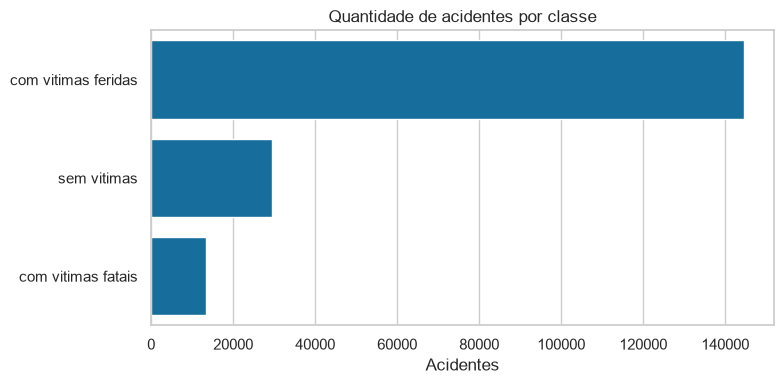

In [8]:
distribuicao_alvo = (
    acidentes[COLUNA_ALVO]
    .fillna("ausente")
    .value_counts()
    .rename_axis(COLUNA_ALVO)
    .reset_index(name="quantidade")
)
distribuicao_alvo["percentual"] = (
    distribuicao_alvo["quantidade"].div(len(acidentes)).mul(100).round(2)
)

display(distribuicao_alvo)

dados_grafico = distribuicao_alvo.query(f"{COLUNA_ALVO} != 'ausente'")
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=dados_grafico, x="quantidade", y=COLUNA_ALVO, ax=ax)
ax.set(title="Quantidade de acidentes por classe", xlabel="Acidentes", ylabel="")
fig.tight_layout()
fig.savefig(PASTA_FIGURAS / "eda_distribuicao_alvo.png", dpi=160)
plt.show()

A classe associada a acidentes fatais apresenta frequência substancialmente menor que as demais. Esse desbalanceamento pode influenciar o aprendizado e, portanto, deve ser considerado na escolha das métricas e na avaliação do modelo.

## 6. Avaliação de vazamento do alvo

O vazamento do alvo ocorre quando uma variável preditora contém informação que revela direta ou indiretamente o desfecho. Como `mortos` e `feridos` participam da definição da classificação do acidente, essas variáveis não podem ser utilizadas como entradas do modelo.

In [9]:
alvo_recriado = pd.Series("sem vitimas", index=acidentes.index, dtype="string")
alvo_recriado.loc[acidentes["feridos"].gt(0)] = "com vitimas feridas"
alvo_recriado.loc[acidentes["mortos"].gt(0)] = "com vitimas fatais"

possui_alvo = acidentes[COLUNA_ALVO].notna()
quantidade_divergente = (
    acidentes.loc[possui_alvo, COLUNA_ALVO] != alvo_recriado.loc[possui_alvo]
).sum()

print(f"Linhas em que o alvo diverge de mortos/feridos: {quantidade_divergente:,}")

Linhas em que o alvo diverge de mortos/feridos: 0


### 6.1 Verificações de consistência

As verificações a seguir avaliam relações esperadas entre variáveis e identificam valores incompatíveis com os domínios definidos.

In [10]:
nomes_dias = {
    0: "segunda-feira",
    1: "terca-feira",
    2: "quarta-feira",
    3: "quinta-feira",
    4: "sexta-feira",
    5: "sabado",
    6: "domingo",
}
dia_esperado = acidentes["data_inversa"].dt.dayofweek.map(nomes_dias)
horas = pd.to_numeric(acidentes["horario"].astype("string").str[:2], errors="coerce")

verificacoes = pd.DataFrame(
    {
        "verificacao": [
            "feridos diferente de leves + graves",
            "dia da semana diferente da data",
            "horario invalido",
            "ICM fora do intervalo de 0 a 100",
            "volume de pedagio negativo",
        ],
        "linhas_com_problema": [
            (
                acidentes["feridos"]
                != acidentes["feridos_leves"] + acidentes["feridos_graves"]
            ).sum(),
            (acidentes["dia_semana"] != dia_esperado).sum(),
            (horas.isna() | ~horas.between(0, 23)).sum(),
            (acidentes["icm"].notna() & ~acidentes["icm"].between(0, 100)).sum(),
            (
                acidentes["volume_pedagio"].notna() & acidentes["volume_pedagio"].lt(0)
            ).sum(),
        ],
    }
)

display(verificacoes)

,verificacao,linhas_com_problema
0,feridos diferente de leves + graves,0
1,dia da semana diferente da data,51840
2,horario invalido,0
3,ICM fora do intervalo de 0 a 100,0
4,volume de pedagio negativo,0


## 7. Caracterização das variáveis numéricas

As estatísticas descritivas sintetizam a tendência central, a dispersão e a amplitude das variáveis numéricas selecionadas. Esse exame também auxilia na identificação de diferenças de escala e de possíveis valores extremos.

In [11]:
numericas_existentes = ["km", "volume_pedagio", "icm"]
display(acidentes[numericas_existentes].describe().T.round(2))

,count,mean,std,min,25%,50%,75%,max
km,187351.0,258.7,227.15,0.0,75.6,191.8,407.0,1470.0
volume_pedagio,110022.0,525787.48,505530.68,1.0,160376.0,353285.0,727404.0,2619447.0
icm,110383.0,21.97,15.54,0.0,9.75,18.0,28.75,100.0


## 8. Análise espacial

Esta seção compara a quantidade de acidentes entre os estados e entre os trechos das rodovias federais. Ao final, o mapa mostra como os acidentes estão distribuídos pelo território brasileiro.

### 8.1 Estados com mais acidentes

Como cada linha do conjunto de dados representa um acidente, a função `value_counts()` pode ser usada para contar quantas vezes cada unidade federativa (`uf`) aparece. O ranking abaixo apresenta os dez estados com mais registros de acidentes.

,uf,quantidade
0,MG,24207
1,SC,21457
2,PR,19693
3,RJ,16487
4,RS,12867
5,SP,12246
6,BA,10626
7,GO,8430
8,PE,8128
9,MT,6665


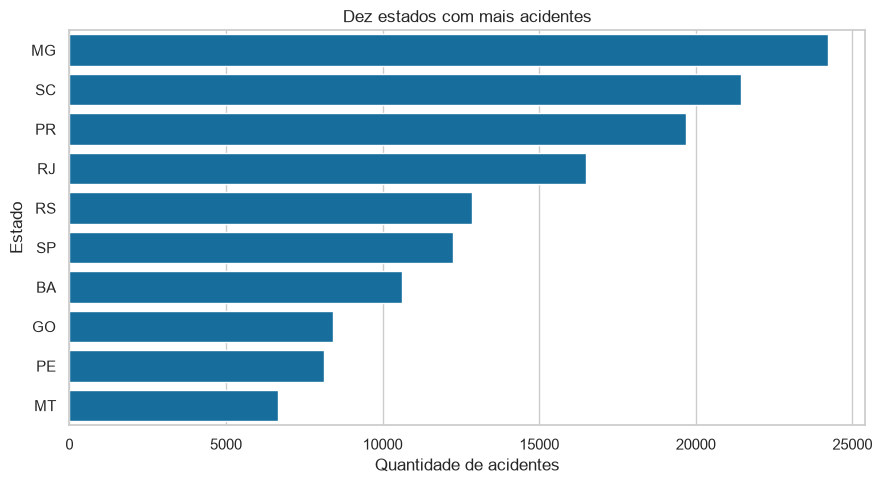

In [12]:
estados_mais_acidentes = (
    acidentes["uf"]
    .value_counts()
    .head(10)
    .rename_axis("uf")
    .reset_index(name="quantidade")
)

display(estados_mais_acidentes)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(
    data=estados_mais_acidentes,
    x="quantidade",
    y="uf",
    ax=ax,
)
ax.set_title("Dez estados com mais acidentes")
ax.set_xlabel("Quantidade de acidentes")
ax.set_ylabel("Estado")
fig.tight_layout()
fig.savefig(PASTA_FIGURAS / "eda_estados_mais_acidentes.png", dpi=160)
plt.show()

### 8.2 Trechos de BR com mais acidentes

Para evitar analisar cada marca de quilômetro isoladamente, as rodovias são divididas em trechos de 10 km. A expressão `(km // 10) * 10` encontra o início do trecho: por exemplo, o km 37 pertence ao trecho que começa no km 30 e termina antes do km 40. A UF também faz parte do agrupamento porque a contagem dos quilômetros pode mudar ao atravessar a divisa de um estado.

,trecho,quantidade
0,BR-101 / SC (km 200 a 210),1479
1,BR-116 / SP (km 220 a 230),1056
2,BR-101 / SC (km 210 a 220),910
3,BR-116 / SP (km 210 a 220),887
4,BR-381 / MG (km 480 a 490),788
5,BR-101 / SC (km 130 a 140),788
6,BR-116 / RJ (km 180 a 190),764
7,BR-116 / RJ (km 170 a 180),712
8,BR-101 / PE (km 60 a 70),675
9,BR-40 / RJ (km 110 a 120),673


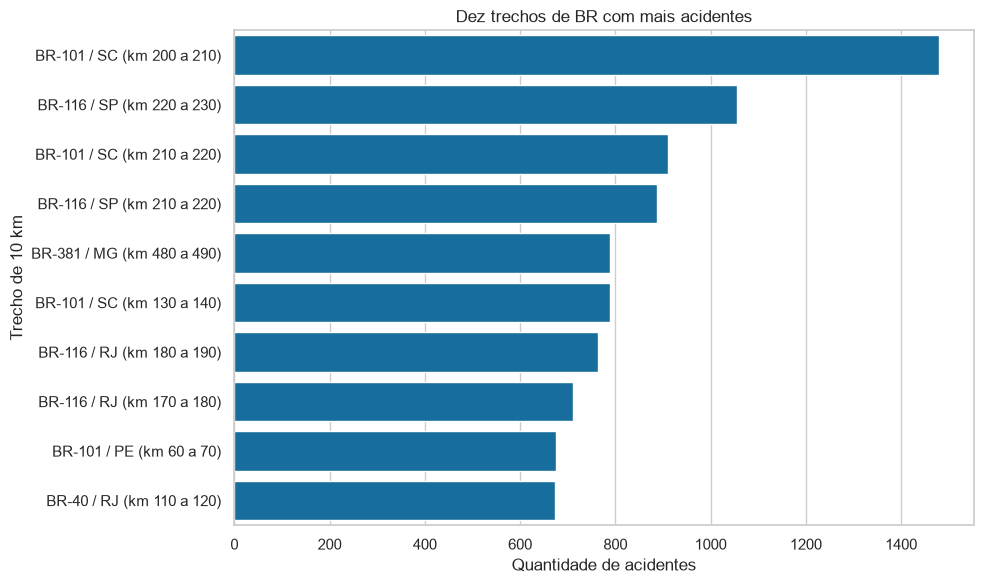

In [13]:
dados_trechos = acidentes[["uf", "br", "km"]].dropna().copy()
dados_trechos["inicio_km"] = (dados_trechos["km"] // 10) * 10

trechos_mais_acidentes = (
    dados_trechos.groupby(["uf", "br", "inicio_km"])
    .size()
    .reset_index(name="quantidade")
    .sort_values("quantidade", ascending=False)
    .head(10)
    .reset_index(drop=True)
)
trechos_mais_acidentes["fim_km"] = trechos_mais_acidentes["inicio_km"] + 10
trechos_mais_acidentes["trecho"] = (
    "BR-"
    + trechos_mais_acidentes["br"].astype(str)
    + " / "
    + trechos_mais_acidentes["uf"]
    + " (km "
    + trechos_mais_acidentes["inicio_km"].astype(int).astype(str)
    + " a "
    + trechos_mais_acidentes["fim_km"].astype(int).astype(str)
    + ")"
)

display(trechos_mais_acidentes[["trecho", "quantidade"]])

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=trechos_mais_acidentes,
    x="quantidade",
    y="trecho",
    ax=ax,
)
ax.set_title("Dez trechos de BR com mais acidentes")
ax.set_xlabel("Quantidade de acidentes")
ax.set_ylabel("Trecho de 10 km")
fig.tight_layout()
fig.savefig(PASTA_FIGURAS / "eda_trechos_br_mais_acidentes.png", dpi=160)
plt.show()

### 8.3 Distribuição dos acidentes no mapa

As colunas `longitude` e `latitude` permitem representar espacialmente cada ocorrência. Inicialmente, são avaliadas coordenadas ausentes e posições externas aos limites aproximados do Brasil. Os registros válidos são então convertidos em um `GeoDataFrame` no sistema de referência `EPSG:4326`.

In [14]:
coordenadas = acidentes[["longitude", "latitude", COLUNA_ALVO]].copy()
coordenadas["longitude"] = pd.to_numeric(coordenadas["longitude"], errors="coerce")
coordenadas["latitude"] = pd.to_numeric(coordenadas["latitude"], errors="coerce")

possui_coordenadas = coordenadas[["longitude", "latitude"]].notna().all(axis=1)
dentro_dos_limites = coordenadas["longitude"].between(-74, -34) & coordenadas[
    "latitude"
].between(-34, 6)

resumo_coordenadas = pd.DataFrame(
    {
        "verificacao": [
            "total de acidentes",
            "sem coordenadas completas",
            "fora dos limites aproximados do Brasil",
        ],
        "quantidade": [
            len(coordenadas),
            (~possui_coordenadas).sum(),
            (possui_coordenadas & ~dentro_dos_limites).sum(),
        ],
    }
)
display(resumo_coordenadas)

usar_no_mapa = (
    possui_coordenadas & dentro_dos_limites & coordenadas[COLUNA_ALVO].notna()
)
dados_geograficos = coordenadas.loc[usar_no_mapa].copy()
acidentes_geo = gpd.GeoDataFrame(
    dados_geograficos,
    geometry=gpd.points_from_xy(
        dados_geograficos["longitude"], dados_geograficos["latitude"]
    ),
    crs="EPSG:4326",
)

print(f"Acidentes no GeoDataFrame: {len(acidentes_geo):,}")
print(f"Sistema de referência: {acidentes_geo.crs}")
display(acidentes_geo.head())

,verificacao,quantidade
0,total de acidentes,187351
1,sem coordenadas completas,0
2,fora dos limites aproximados do Brasil,1


Acidentes no GeoDataFrame: 187,347
Sistema de referência: EPSG:4326


,longitude,latitude,classificacao_acidente,geometry
0,-45.14219,-22.801686,com vitimas fatais,POINT (-45.14219 -22.80169)
1,-40.406504,-19.65107,sem vitimas,POINT (-40.4065 -19.65107)
2,-48.42123,-24.957814,com vitimas feridas,POINT (-48.42123 -24.95781)
3,-52.591459,-31.523214,com vitimas feridas,POINT (-52.59146 -31.52321)
4,-35.243303,-8.113949,com vitimas feridas,POINT (-35.2433 -8.11395)


A contextualização cartográfica utiliza a malha das unidades federativas disponibilizada pelo IBGE. O arquivo correspondente deve estar presente na pasta de dados brutos antes da execução do notebook.

In [15]:
ARQUIVO_MALHA_ESTADOS = (
    RAIZ_PROJETO
    / "data"
    / "01_raw"
    / "ibge"
    / "malha_estados"
    / "2025"
    / "malha_estados_2025.geojson"
)

malha_estados = gpd.read_file(ARQUIVO_MALHA_ESTADOS)
print(f"Unidades federativas carregadas: {len(malha_estados)}")
print(f"Sistema de referência: {malha_estados.crs}")

Unidades federativas carregadas: 27
Sistema de referência: EPSG:4326


Para representar a concentração espacial, os pontos e os limites estaduais são projetados em `EPSG:5880`. Após o recorte pelo território brasileiro, as ocorrências são agregadas em células hexagonais. A escala de cores indica o número de acidentes em escala logarítmica, e as linhas delimitam as unidades federativas.

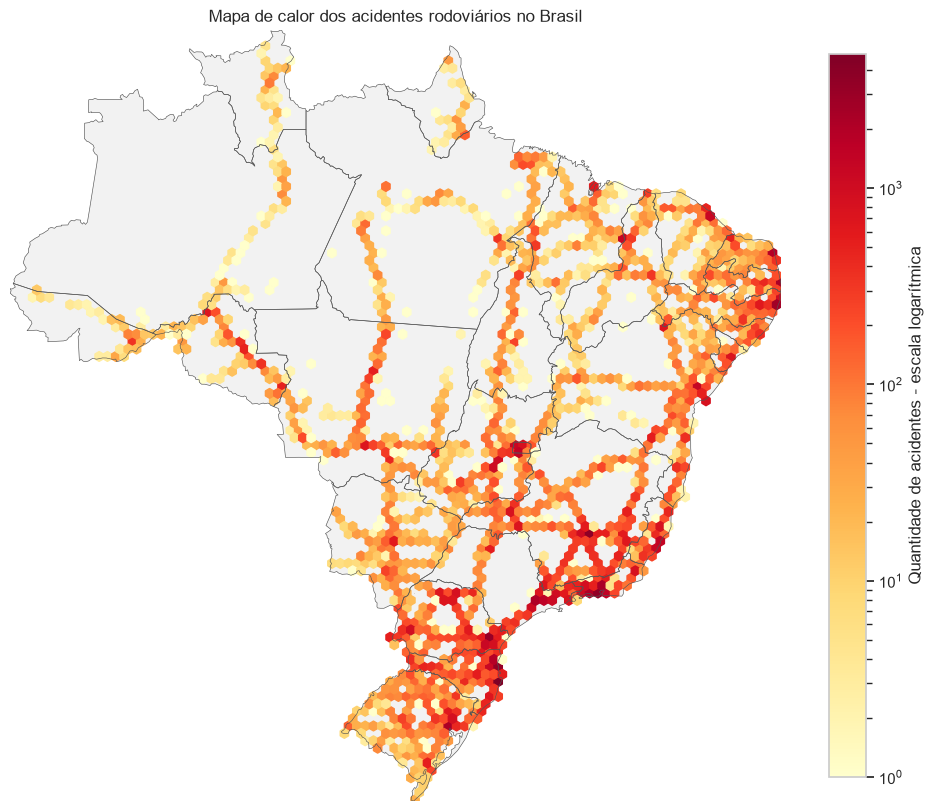

In [16]:
malha_estados_projetada = malha_estados.to_crs("EPSG:5880")
acidentes_projetados = acidentes_geo.to_crs("EPSG:5880")
acidentes_no_brasil = gpd.clip(acidentes_projetados, malha_estados_projetada)

fig, ax = plt.subplots(figsize=(10, 10))
malha_estados_projetada.plot(ax=ax, facecolor="#f2f2f2", edgecolor="none", zorder=1)
mapa_calor = ax.hexbin(
    acidentes_no_brasil.geometry.x,
    acidentes_no_brasil.geometry.y,
    gridsize=90,
    bins="log",
    mincnt=1,
    cmap="YlOrRd",
    zorder=2,
)
malha_estados_projetada.boundary.plot(ax=ax, color="#555555", linewidth=0.45, zorder=3)
barra_cores = fig.colorbar(mapa_calor, ax=ax, shrink=0.75)
barra_cores.set_label("Quantidade de acidentes - escala logarítmica")
ax.set_title("Mapa de calor dos acidentes rodoviários no Brasil")
limite_oeste, limite_sul, limite_leste, limite_norte = (
    malha_estados_projetada.total_bounds
)
ax.set_xlim(limite_oeste, limite_leste)
ax.set_ylim(limite_sul, limite_norte)
ax.set_aspect("equal")
ax.set_axis_off()
fig.tight_layout()
fig.savefig(PASTA_FIGURAS / "eda_mapa_calor_acidentes.png", dpi=160)
plt.show()

## 9. Associação entre tipo de acidente e variável alvo

O gráfico compara a distribuição de `classificacao_acidente` entre os 12 valores mais frequentes de `tipo_acidente`. A comparação descreve associações presentes no conjunto de dados, sem estabelecer relação causal.

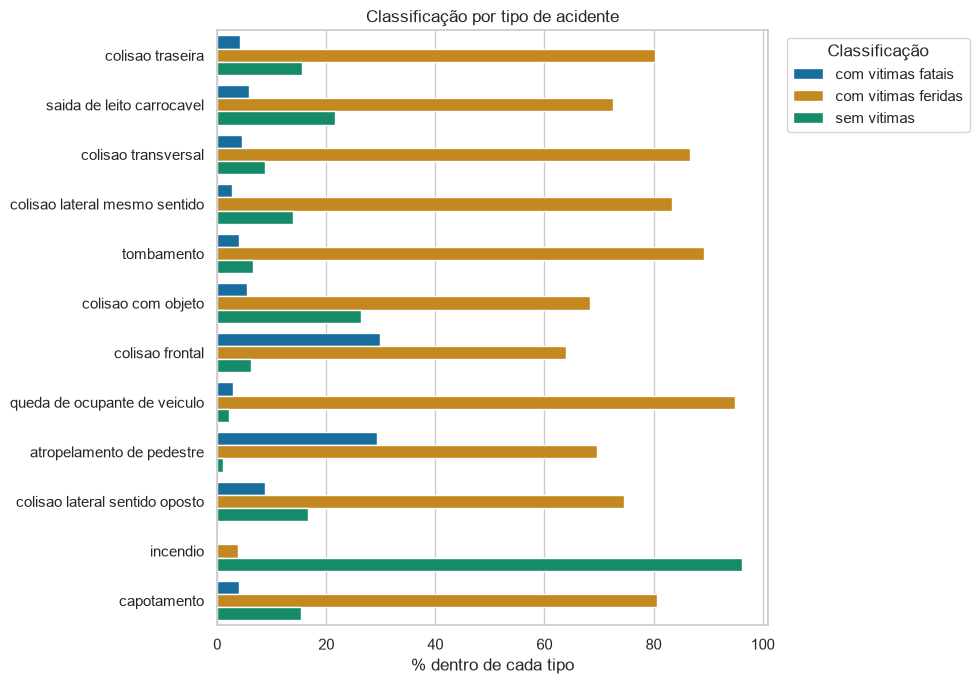

In [17]:
tipos_frequentes = acidentes["tipo_acidente"].value_counts().head(12).index

tipo_por_alvo = (
    acidentes.loc[acidentes["tipo_acidente"].isin(tipos_frequentes)]
    .groupby(["tipo_acidente", COLUNA_ALVO], observed=True)
    .size()
    .rename("quantidade")
    .reset_index()
)
tipo_por_alvo["percentual"] = (
    tipo_por_alvo["quantidade"]
    .div(tipo_por_alvo.groupby("tipo_acidente")["quantidade"].transform("sum"))
    .mul(100)
)

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(
    data=tipo_por_alvo,
    x="percentual",
    y="tipo_acidente",
    hue=COLUNA_ALVO,
    order=tipos_frequentes,
    ax=ax,
)
ax.set(
    title="Classificação por tipo de acidente",
    xlabel="% dentro de cada tipo",
    ylabel="",
)
ax.legend(title="Classificação", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
fig.savefig(
    PASTA_FIGURAS / "eda_tipo_acidente_por_alvo.png", dpi=160, bbox_inches="tight"
)
plt.show()

### 9.1 Categorias em destaque por diferentes critérios

A tabela abaixo mostra, para cada variável categórica selecionada para o modelo, três resultados: a categoria com maior proporção fatal, a categoria com mais acidentes e a categoria com mais acidentes fatais. Elas podem ser diferentes, pois cada critério responde a uma pergunta distinta. São consideradas apenas categorias com pelo menos 100 acidentes. Esse limite evita destacar uma porcentagem alta calculada a partir de poucas ocorrências.

In [18]:
dados_categoricos = construir_features(acidentes)
dados_categoricos["acidente_fatal"] = (
    dados_categoricos[COLUNA_ALVO] == "com vitimas fatais"
)

MINIMO_DE_ACIDENTES = 100
categorias_em_destaque = []

for coluna in COLUNAS_CATEGORICAS:
    # Conta o total de acidentes e quantos foram fatais em cada categoria.
    resumo_da_coluna = (
        dados_categoricos.groupby(coluna, dropna=False)["acidente_fatal"]
        .agg(["count", "sum"])
        .reset_index()
        .rename(columns={"count": "total", "sum": "fatais"})
    )

    resumo_da_coluna = resumo_da_coluna[
        resumo_da_coluna["total"] >= MINIMO_DE_ACIDENTES
    ].copy()
    resumo_da_coluna["percentual_fatal"] = (
        resumo_da_coluna["fatais"] / resumo_da_coluna["total"] * 100
    )

    maior_proporcao = resumo_da_coluna.sort_values(
        "percentual_fatal", ascending=False
    ).iloc[0]
    mais_acidentes = resumo_da_coluna.sort_values(
        "total", ascending=False
    ).iloc[0]
    mais_acidentes_fatais = resumo_da_coluna.sort_values(
        "fatais", ascending=False
    ).iloc[0]

    categorias_em_destaque.append(
        {
            "variavel": coluna,
            "categoria_maior_proporcao_fatal": maior_proporcao[coluna],
            "percentual_fatal": maior_proporcao["percentual_fatal"],
            "categoria_com_mais_acidentes": mais_acidentes[coluna],
            "quantidade_acidentes": mais_acidentes["total"],
            "categoria_com_mais_fatais": mais_acidentes_fatais[coluna],
            "quantidade_fatais": mais_acidentes_fatais["fatais"],
        }
    )

categorias_em_destaque = pd.DataFrame(
    categorias_em_destaque
).sort_values("percentual_fatal", ascending=False)
categorias_em_destaque["percentual_fatal"] = (
    categorias_em_destaque["percentual_fatal"].round(2)
)

display(categorias_em_destaque.reset_index(drop=True))

,variavel,categoria_maior_proporcao_fatal,percentual_fatal,categoria_com_mais_acidentes,quantidade_acidentes,categoria_com_mais_fatais,quantidade_fatais
0,br,402,23.39,101,33190,101,1692
1,condicao_meteorologica,nevoeiro/neblina,11.66,ceu claro,118023,ceu claro,8692
2,fase_dia,amanhecer,11.12,pleno dia,104233,plena noite,6488
3,tipo_pista,simples,9.79,simples,90142,simples,8824
4,inclinacao,declive,9.69,nivelado,151095,nivelado,9962
5,dia_semana,domingo,8.75,sabado,30011,domingo,2622
6,reta,curva,8.09,reta,152633,reta,10515


## 10. Seleção das variáveis preditoras

A seleção procura preservar informações potencialmente úteis sem introduzir vazamento do alvo. A relação de variáveis é obtida diretamente do módulo de preparação, assegurando consistência entre a análise exploratória e o pipeline.

In [19]:
contrato_features = pd.DataFrame(
    {
        "feature": COLUNAS_FEATURES,
        "tipo": (
            ["categorica"] * len(COLUNAS_CATEGORICAS)
            + ["numerica"] * len(COLUNAS_NUMERICAS)
        ),
    }
)

display(contrato_features)

,feature,tipo
0,dia_semana,categorica
1,br,categorica
2,fase_dia,categorica
3,condicao_meteorologica,categorica
4,tipo_pista,categorica
5,inclinacao,categorica
6,reta,categorica
7,km,numerica
8,volume_pedagio,numerica
9,icm,numerica


As demais colunas são excluídas pelos seguintes critérios:

- identificação do registro: `id` possui função exclusivamente identificadora;
- localização direta: `uf`, `municipio`, `latitude`, `longitude`, `regional`, `delegacia` e `uop`;
- vazamento do alvo: contagens de mortos, feridos e outras consequências observadas após o acidente;
- informações transformadas: `tracado_via` é representada por `inclinacao` e `reta`, enquanto `causa_acidente` origina `fator_humano`;
- variáveis não selecionadas: `tipo_acidente`, `uso_solo`, `data_inversa` e `horario`.

Em aplicações prospectivas, a disponibilidade temporal de `icm`, `volume_pedagio` e da informação utilizada para construir `fator_humano` deve ser verificada. Essas variáveis somente são adequadas se estiverem disponíveis no momento em que a previsão for realizada.

## 11. Construção do conjunto final

A função `construir_features` aplica as transformações definidas no projeto. O conjunto resultante contém somente as variáveis preditoras selecionadas e a coluna alvo, sendo posteriormente armazenado para a etapa de modelagem.

In [20]:
dados_modelo = construir_features(acidentes)

ARQUIVO_SAIDA.parent.mkdir(parents=True, exist_ok=True)
dados_modelo.to_parquet(ARQUIVO_SAIDA, index=False)

print(f"Linhas do conjunto final: {len(dados_modelo):,}")
print(f"Features: {len(COLUNAS_FEATURES)}")
print(f"Arquivo salvo em: {ARQUIVO_SAIDA}")
display(dados_modelo.head())

Linhas do conjunto final: 187,348
Features: 11
Arquivo salvo em: C:\Users\vitor\Documents\ufsc\2026_2\Ciência de dados\prf-accidents-feature-importance\data\03_processed\acidentes_features.parquet


,dia_semana,br,fase_dia,condicao_meteorologica,tipo_pista,inclinacao,reta,km,volume_pedagio,icm,fator_humano,classificacao_acidente
0,quinta-feira,116,plena noite,chuva,dupla,nivelado,reta,59.9,1419025.0,<NA>,1,com vitimas fatais
1,quinta-feira,259,amanhecer,nublado,simples,nivelado,reta,12.8,<NA>,19.5,0,sem vitimas
2,quinta-feira,116,plena noite,ceu claro,simples,declive,curva,544.0,755787.0,<NA>,1,com vitimas feridas
3,quinta-feira,392,amanhecer,ceu claro,simples,nivelado,reta,102.4,119287.0,22.5,1,com vitimas feridas
4,quinta-feira,232,pleno dia,ceu claro,dupla,nivelado,reta,41.0,<NA>,<NA>,1,com vitimas feridas


## Conclusão

A análise resultou em um conjunto de dados estruturado, com exclusão das variáveis que revelam diretamente a classificação do acidente. As etapas subsequentes compreendem a separação entre treino e teste, o tratamento dos valores ausentes, o treinamento dos modelos e a avaliação de seu desempenho.